<a href="https://colab.research.google.com/github/JNario31/LinearModels/blob/main/LinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# download boston house data from Google drive

!gdown --folder https://drive.google.com/drive/folders/12L9XNwhIH2wQBa4-IdQrhsrtgRFbeIMZ 2> /dev/null

Processing file 1IZf0tFGW3Zv3Ax5gxKgnklHe1DUI7CAI boston.csv


In [4]:
# load Boston House data set
import pandas as pd
import numpy as np

raw_data = pd.read_csv('Boston/boston.csv', header=None)
data_rows = np.reshape(raw_data.to_numpy(), (506,14)) # 506 - number of observations (houses) 14 - number of variables
data = data_rows[:,:13]
target = data_rows[:,13]

# normalize input features to zero-mean and unit-variance
# np.mean(data, axis=0) calculates mean of features across 506 observations
# np.std(data, axis=0) calculates standard deviation of features across 506 observations
# Data is normalized by subtracting each data point by the mean, then dividing it by the std
# Each feature will have a mean of approximately 0 and a std of 1
data = (data-np.mean(data, axis=0))/np.std(data, axis=0)

print(data.shape)
print(target.shape)

(506, 13)
(506,)


In [5]:
# add a constant column of '1' to accomodate the bias (see the margin note on page 107)
data_wb = np.hstack((data, np.ones((data.shape[0], 1), dtype=data.dtype)))

print(data_wb.shape)

# calculate weights with closed form solution - w = (X^TX)^-1X^Ty
w = np.linalg.inv(data_wb.T @ data_wb) @ data_wb.T @ target

# calculate the mean square error in the training set
predict = data_wb @ w
error = np.sum((predict - target)*(predict - target))/data.shape[0]

print(f'mean square error for the closed-form solution: {error:.5f}')

(506, 14)
mean square error for the closed-form solution: 21.89483


In [6]:
# solve linear regression using gradient descent (autograd)
import numpy as np
import jax.numpy as jnp
from jax import grad

# Optimizer:
class Optimizer():
  def __init__(self, lr, annealing_rate, batch_size, max_epochs):
    self.lr = lr                          # Inital learning rate
    self.annealing_rate = annealing_rate  # Learning rate decay factor
    self.batch_size = batch_size          # Mini batch sizes
    self.max_epochs = max_epochs          # number of dataset iterations

# Average of squared differences of prediction and target values
def obj_func(w, X, y):
  diff = X @ w - y  # prediction difference
  return jnp.sum(diff*diff)/X.shape[0]

# X[N,d]: input features; y[N]: output targets; op: hyper-parameters for optimzer
def linear_regression_gd(X, y, op):
  n = X.shape[0]   # number of samples
  w = jnp.zeros(X.shape[1])  # initialization

  lr = op.lr
  errors = np.zeros(op.max_epochs)
  for epoch in range(op.max_epochs):
    indices = np.random.permutation(n)  #randomly shuffle data indices
    for batch_start in range(0, n, op.batch_size):
      X_batch = X[indices[batch_start:batch_start + op.batch_size]]
      y_batch = y[indices[batch_start:batch_start + op.batch_size]]

      # compute gradients via auto-grad for a whole mini-batch
      # minimize the loss function by computing the gradient with respect to w
      w_grad = grad(obj_func)(w, X_batch, y_batch)

      # update weight by moving in the opposite direction of the gradient
      w -= lr * w_grad / X_batch.shape[0]

    # store and compute MSE of epoch
    errors[epoch] = obj_func(w, X, y)
    # decay learning rate
    lr *= op.annealing_rate

  return w, np.array(errors)

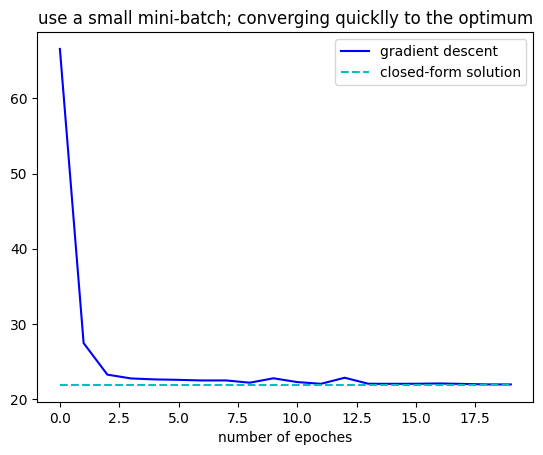

In [7]:
import matplotlib.pyplot as plt

op = Optimizer(lr=0.005, annealing_rate=0.99, batch_size=2, max_epochs=20)

w, errors = linear_regression_gd(data_wb, target, op)

plt.title('use a small mini-batch; converging quicklly to the optimum')
plt.xlabel('number of epoches')
plt.plot(errors, 'b', 21.89*np.ones(errors.shape[0]), 'c--')
plt.legend(['gradient descent', 'closed-form solution'])

Small mini batches converge quickly

Large mini batches converge smoothly, although not close to the closed form solution

Large mini batches converge smoothly and when paired with a larger learning rate, converges more nicely

Overly large learning rates, it does not converge